# Análisis de Cluster — Dataset de Fórmula 1

**Análisis Multivariado y Descubrimiento de Patrones**  
Licenciatura en Ciencia de Datos

---

**Unidad de análisis:** driver–temporada (misma que en el PCA).  
**Período:** 2004–2024 (464 observaciones con datos completos).  
**Objetivo:** agrupar las temporadas de pilotos según su perfil de desempeño y caracterizar cada grupo en términos del dominio F1.

## 1. Importación de librerías

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

DATA_PATH  = '../../data/raw/'
FIGS_PATH  = '../../reports/figures/'
SEED       = 42

## 2. Carga y preprocesamiento de datos

*(Idéntico al notebook de PCA. Se repite para que el notebook sea autocontenido.)*

In [50]:
races        = pd.read_csv(DATA_PATH + 'races.csv')
results      = pd.read_csv(DATA_PATH + 'results.csv')
drivers      = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')

# Filtrar desde 2004 y unir tablas
races_mod = races[races['year'] >= 2004][['raceId', 'year', 'name']].copy()
df = results.merge(races_mod, on='raceId')
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
df = df.merge(drivers[['driverId', 'driver_name', 'nationality']], on='driverId')
df = df.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructor'}),
    on='constructorId'
)

# Limpieza
df['position']        = pd.to_numeric(df['position'].replace('\\N', np.nan), errors='coerce')
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'].replace('\\N', np.nan), errors='coerce')
df['grid']            = pd.to_numeric(df['grid'], errors='coerce')
df.loc[df['grid'] == 0, 'grid'] = np.nan

df['is_dnf']    = df['position'].isna().astype(int)
df['is_win']    = (df['position'] == 1).astype(int)
df['is_podium'] = (df['position'] <= 3).fillna(0).astype(int)
df['rel_speed'] = df.groupby('raceId')['fastestLapSpeed'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

# Escudería principal por driver-temporada
main_constructor = (
    df.groupby(['year', 'driverId', 'constructor'])
    .size().reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates(['year', 'driverId'])
    [['year', 'driverId', 'constructor']]
)

# Agregación a nivel driver-temporada
driver_season = (
    df.groupby(['year', 'driverId', 'driver_name', 'nationality'])
    .agg(
        n_races         = ('raceId',        'count'),
        avg_grid        = ('grid',          'mean'),
        avg_pos_order   = ('positionOrder', 'mean'),
        points_per_race = ('points',        'mean'),
        win_rate        = ('is_win',        'mean'),
        podium_rate     = ('is_podium',     'mean'),
        dnf_rate        = ('is_dnf',        'mean'),
        avg_rel_speed   = ('rel_speed',     'mean'),
    )
    .reset_index()
    .merge(main_constructor, on=['year', 'driverId'])
)
driver_season = driver_season[driver_season['n_races'] >= 5].copy()

def asignar_era(year):
    if year <= 2009:   return 'V10/V8 (2004-09)'
    elif year <= 2013: return 'V8 (2010-13)'
    elif year <= 2021: return 'Híbrido (2014-21)'
    else:              return 'Nuevos reglamentos (2022+)'

driver_season['era'] = driver_season['year'].apply(asignar_era)

NUMERIC_VARS = ['avg_grid', 'avg_pos_order', 'points_per_race',
                'win_rate', 'podium_rate', 'dnf_rate', 'avg_rel_speed']

LABELS_SHORT = {
    'avg_grid':         'Grid prom.',
    'avg_pos_order':    'Pos. llegada prom.',
    'points_per_race':  'Puntos/carrera',
    'win_rate':         'Tasa victorias',
    'podium_rate':      'Tasa podios',
    'dnf_rate':         'Tasa abandono',
    'avg_rel_speed':    'Vel. relativa',
}

ERA_COLORS = {
    'V10/V8 (2004-09)':           '#2196F3',
    'V8 (2010-13)':               '#4CAF50',
    'Híbrido (2014-21)':          '#FF9800',
    'Nuevos reglamentos (2022+)': '#9C27B0',
}

# Dataset completo para clustering (mismas filas que el PCA)
clust_df = driver_season[NUMERIC_VARS + ['driver_name','year','nationality','constructor','era','n_races']].dropna().copy()

X        = clust_df[NUMERIC_VARS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset para clustering: {clust_df.shape}")
print(f"Período: {clust_df['year'].min()}–{clust_df['year'].max()}")

Dataset para clustering: (464, 13)
Período: 2004–2024


## 3. Clustering jerárquico

El clustering jerárquico (método de Ward) permite explorar la estructura de agrupamiento de forma visual mediante un dendrograma, sin necesidad de fijar el número de clusters *a priori*.

### 3.1 Dendrograma

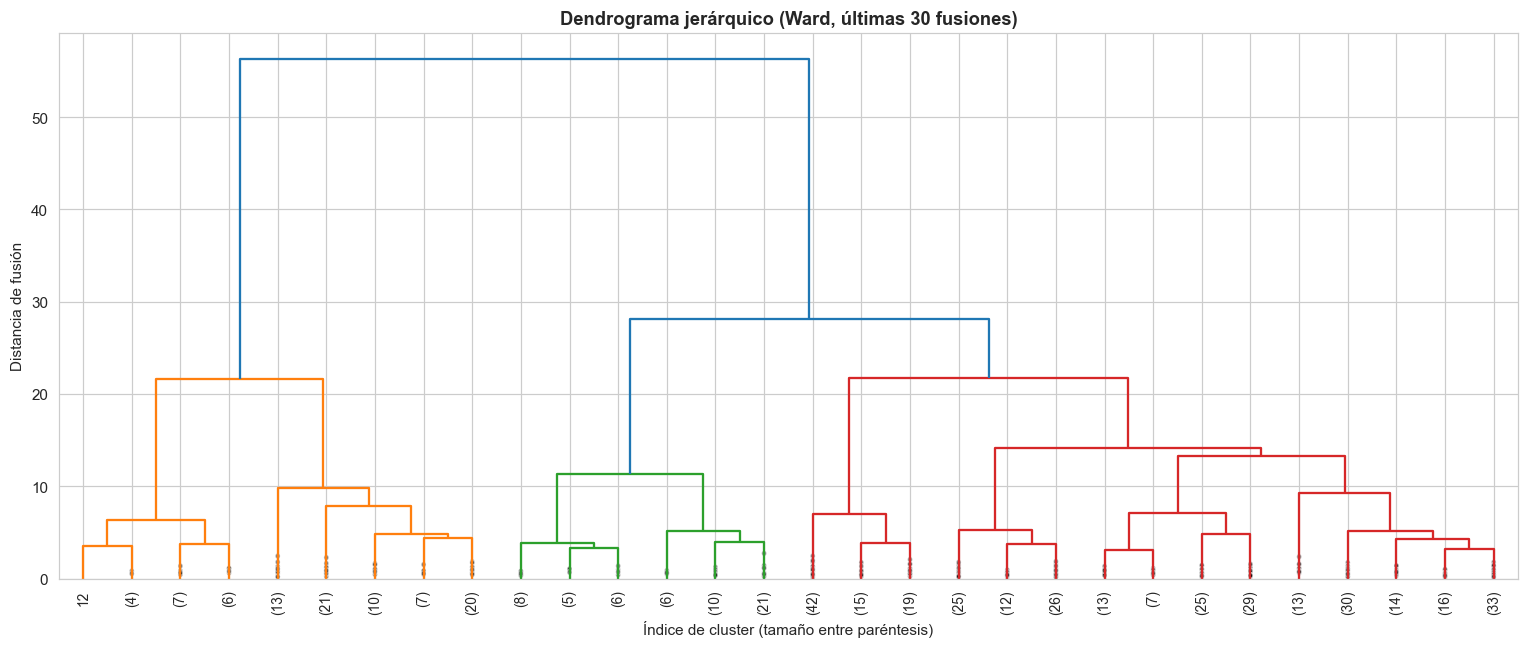

In [51]:
Z = linkage(X_scaled, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',  # mostrar solo las últimas fusiones
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.4 * max(Z[:, 2]),
)
ax.set_title('Dendrograma jerárquico (Ward, últimas 30 fusiones)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Índice de cluster (tamaño entre paréntesis)')
ax.set_ylabel('Distancia de fusión')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_dendrograma.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Correlación cofenética

La correlación cofenética mide qué tan bien el dendrograma preserva las distancias originales entre pares de observaciones. Valores > 0.7 indican buena representación.

In [52]:
from scipy.cluster.hierarchy import cophenet

coph_corr, _ = cophenet(Z, pdist(X_scaled))
print(f"Correlación cofenética (Ward): {coph_corr:.4f}")

Correlación cofenética (Ward): 0.7317


## 4. Selección del número de clusters con K-Means

Se combinan cuatro criterios:
- **Inercia (método del codo):** buscar el punto donde la reducción marginal de inercia decrece abruptamente.
- **Coeficiente de silueta promedio:** maximizar la cohesión intra-cluster y la separación entre clusters.
- **Gap statistic:** comparar la dispersión intra-cluster observada con la esperada bajo datos de referencia uniformes (Tibshirani et al., 2001).
- **Dendrograma:** cortes visuales en el árbol jerárquico.

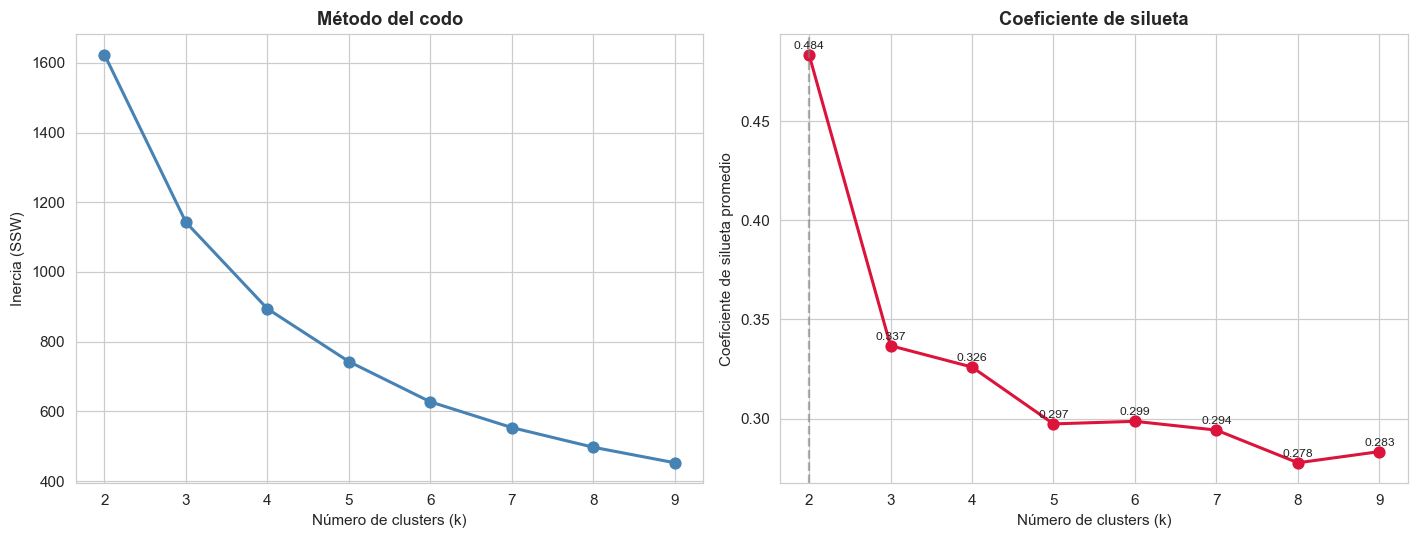

k con mayor silueta: 2 (silueta = 0.4835)


In [53]:
K_RANGE = range(2, 10)

inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Inercia
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (SSW)')
axes[0].set_title('Método del codo', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

# Silueta
best_k = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='crimson', linewidth=2, markersize=7)
axes[1].axvline(best_k, color='gray', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silueta promedio')
axes[1].set_title('Coeficiente de silueta', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))

# Anotar valores
for k, s in zip(K_RANGE, silhouettes):
    axes[1].text(k, s + 0.003, f'{s:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_seleccion_k.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"k con mayor silueta: {best_k} (silueta = {max(silhouettes):.4f})")

### 4.1 Gráfico de silueta por observación

k elegido: 4
Silueta global: 0.3260  (referencia: k=2 → 0.4835, k=3 → 0.3368, k=4 → 0.3260)


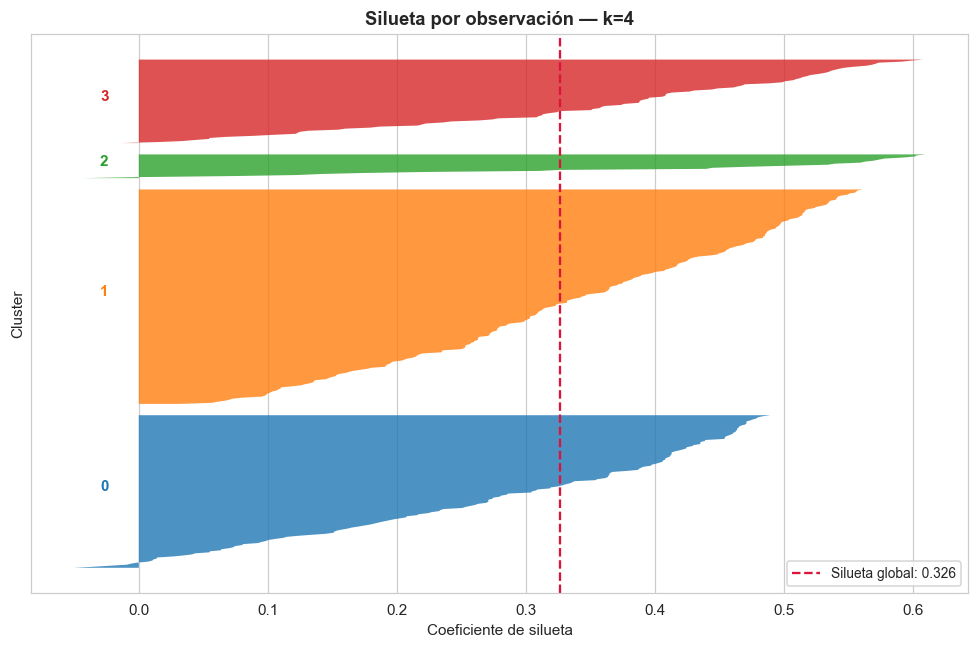

In [54]:
# La silueta es máxima en k=2, pero ese valor solo separa 'top performers'
# del resto del pelotón —una separación demasiado gruesa para el análisis F1.
# El método del codo marca un quiebre en k=3 o k=4 y, con k=4, se obtienen
# grupos con interpretación clara (campeones / frontrunners / midfield / traseros).
# Se puede cambiar este valor para explorar otras granularidades.
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, n_init=20, random_state=SEED)
clust_df['cluster'] = km_final.fit_predict(X_scaled)

sil_vals   = silhouette_samples(X_scaled, clust_df['cluster'])
sil_global = silhouette_score(X_scaled, clust_df['cluster'])

print(f"k elegido: {K_FINAL}")
print(f"Silueta global: {sil_global:.4f}  (referencia: k=2 → 0.4835, k=3 → 0.3368, k=4 → 0.3260)")

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
palette = plt.cm.tab10.colors

for c in range(K_FINAL):
    vals_c = np.sort(sil_vals[clust_df['cluster'] == c])
    size_c = len(vals_c)
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_c,
                     facecolor=palette[c], edgecolor='none', alpha=0.8)
    ax.text(-0.03, y_lower + size_c / 2, str(c), fontsize=10, color=palette[c],
            fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(sil_global, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Silueta global: {sil_global:.3f}')
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Cluster')
ax.set_title(f'Silueta por observación — k={K_FINAL}', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_silueta.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 Gap Statistic

El *gap statistic* (Tibshirani et al., 2001) compara la dispersión intra-cluster del dato real con la esperada bajo una distribución de referencia uniforme sobre el mismo bounding box. Se elige **k\*** como el menor k tal que Gap(k) ≥ Gap(k+1) − s_{k+1}, donde s es el desvío estándar de las réplicas de referencia.

In [ ]:
def gap_statistic(X, k_range, n_refs=50, random_state=SEED):
    rng = np.random.RandomState(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)
    gaps, sdks = [], []
    for k in k_range:
        Wk = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(X).inertia_
        log_Wk_refs = []
        for _ in range(n_refs):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            log_Wk_refs.append(
                np.log(KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(X_ref).inertia_)
            )
        log_Wk_refs = np.array(log_Wk_refs)
        gaps.append(np.mean(log_Wk_refs) - np.log(Wk))
        sdks.append(np.std(log_Wk_refs) * np.sqrt(1 + 1/n_refs))
    return np.array(gaps), np.array(sdks)

K_RANGE_LIST = list(K_RANGE)
gaps, sdks = gap_statistic(X_scaled, K_RANGE_LIST)

# Regla de Tibshirani: k* = menor k tal que Gap(k) >= Gap(k+1) - sdk(k+1)
gap_opt = K_RANGE_LIST[-1]
for i in range(len(K_RANGE_LIST) - 1):
    if gaps[i] >= gaps[i + 1] - sdks[i + 1]:
        gap_opt = K_RANGE_LIST[i]
        break

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(K_RANGE_LIST, gaps, yerr=sdks, fmt='o-', color='steelblue',
            linewidth=2, markersize=7, capsize=4, elinewidth=1.5)
ax.axvline(gap_opt, color='crimson', linestyle='--', linewidth=1.5,
           label=f'k óptimo = {gap_opt}')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Gap statistic')
ax.set_title('Gap Statistic — selección de k óptimo', fontweight='bold', fontsize=12)
ax.set_xticks(K_RANGE_LIST)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_gap_statistic.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"k óptimo según gap statistic: {gap_opt}")
print()
for k, g, s in zip(K_RANGE_LIST, gaps, sdks):
    marker = " ← óptimo" if k == gap_opt else ""
    print(f"  k={k}: gap={g:.4f} ± {s:.4f}{marker}")

## 5. Caracterización de los clusters

### 5.1 Tamaño de cada cluster

In [55]:
print("Tamaño de cada cluster:")
print(clust_df['cluster'].value_counts().sort_index())

Tamaño de cada cluster:
cluster
0    149
1    209
2     24
3     82
Name: count, dtype: int64


### 5.2 Medias de variables por cluster

In [56]:
cluster_profile = (
    clust_df.groupby('cluster')[NUMERIC_VARS]
    .mean()
    .rename(columns=LABELS_SHORT)
    .round(3)
)
print("Perfil de cada cluster (medias):")
cluster_profile

Perfil de cada cluster (medias):


,Grid prom.,Pos. llegada prom.,Puntos/carrera,Tasa victorias,Tasa podios,Tasa abandono,Vel. relativa
cluster,,,,,,,
0,16.606,15.694,0.255,0.000,0.003,0.287,-0.786
1,10.653,10.980,2.551,0.005,0.048,0.168,0.056
2,3.141,3.342,15.999,0.484,0.780,0.070,1.143
3,5.278,6.163,9.953,0.102,0.419,0.110,0.745


### 5.3 Heatmap del perfil de clusters (variables estandarizadas)

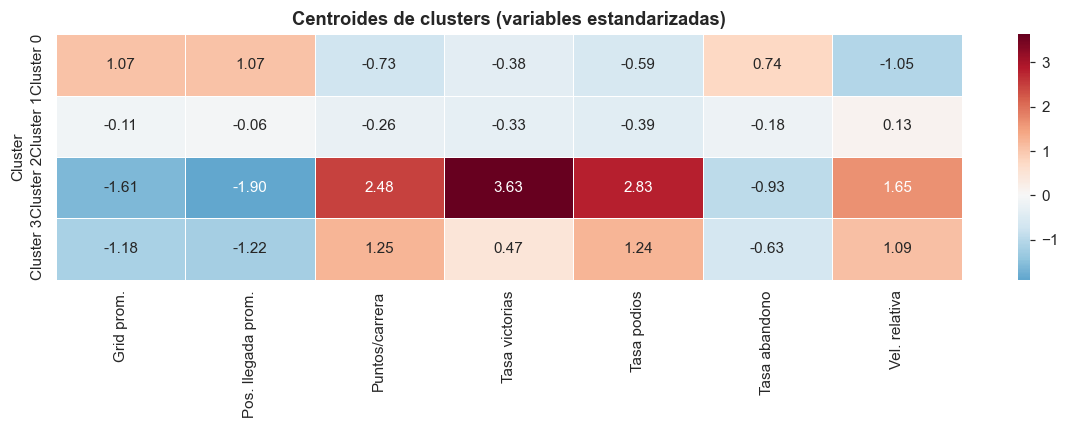

In [57]:
# Centros de K-Means en escala estandarizada → más fácil comparar magnitudes
centers_scaled = pd.DataFrame(
    km_final.cluster_centers_,
    columns=[LABELS_SHORT[v] for v in NUMERIC_VARS],
    index=[f'Cluster {c}' for c in range(K_FINAL)]
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    centers_scaled,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Centroides de clusters (variables estandarizadas)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_heatmap_centros.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Radar chart de perfiles (escala estandarizada)

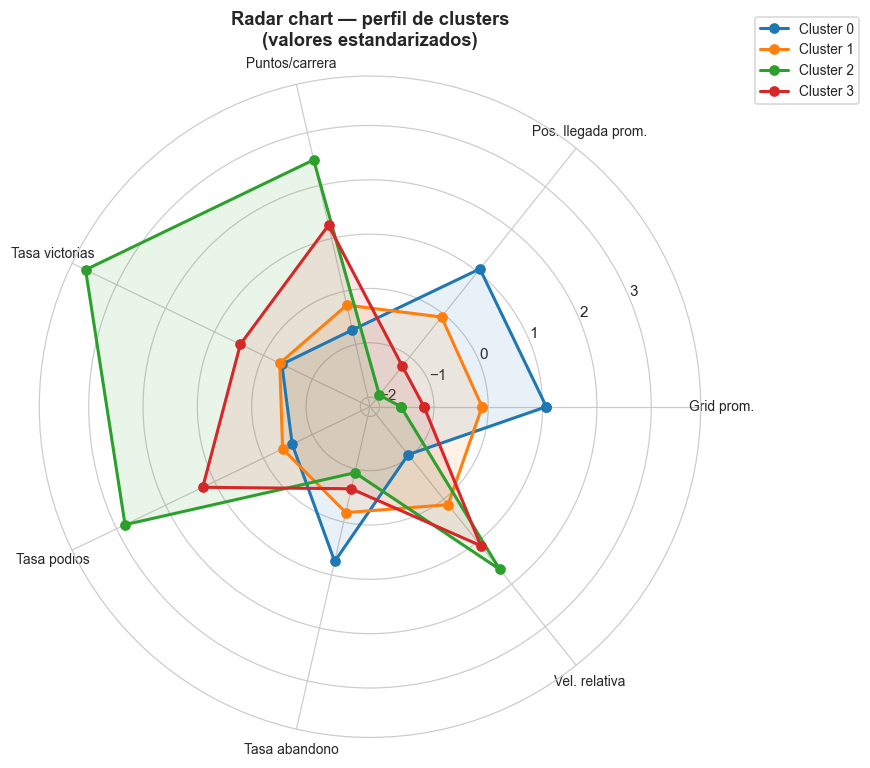

In [58]:
feat_labels = [LABELS_SHORT[v] for v in NUMERIC_VARS]
N = len(feat_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

palette = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in range(K_FINAL):
    values = centers_scaled.iloc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=palette[c], label=f'Cluster {c}')
    ax.fill(angles, values, alpha=0.10, color=palette[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_labels, fontsize=9)
ax.set_title('Radar chart — perfil de clusters\n(valores estandarizados)',
             fontweight='bold', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_radar.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Visualización en el espacio del PCA

### 6.1 Clusters proyectados sobre CP1 y CP2

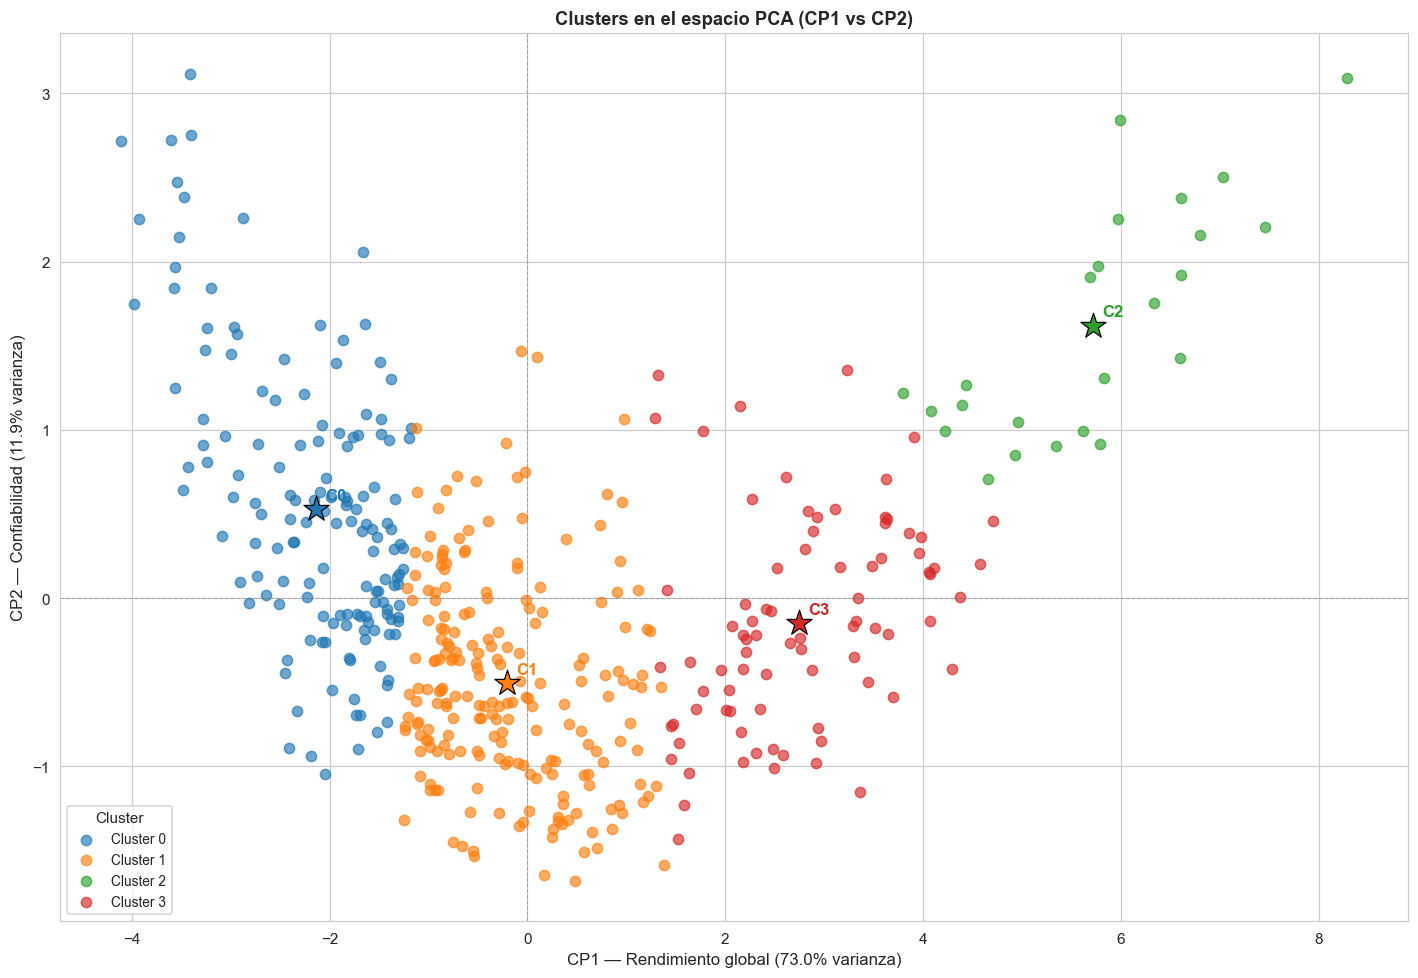

In [59]:
# Reconstruir el PCA con misma convención de signo que en el notebook de PCA
pca = PCA()
scores_raw = pca.fit_transform(X_scaled)

flip = np.ones(pca.n_components_)
if pca.components_[0, NUMERIC_VARS.index('points_per_race')] < 0:
    flip[0] = -1
if pca.components_[1, NUMERIC_VARS.index('dnf_rate')] < 0:
    flip[1] = -1

scores_plot   = scores_raw * flip
loadings_plot = pca.components_.T * flip
var_exp       = pca.explained_variance_ratio_

clust_df['CP1'] = scores_plot[:, 0]
clust_df['CP2'] = scores_plot[:, 1]

# ---- Scatter clusters en espacio PCA ----
fig, ax = plt.subplots(figsize=(13, 9))

for c in range(K_FINAL):
    grp = clust_df[clust_df['cluster'] == c]
    ax.scatter(grp['CP1'], grp['CP2'], c=[palette[c]], label=f'Cluster {c}',
               alpha=0.65, s=45, zorder=2)

# Centroides en espacio PCA
centers_pca = pca.transform(km_final.cluster_centers_) * flip
for c in range(K_FINAL):
    ax.scatter(centers_pca[c, 0], centers_pca[c, 1],
               marker='*', s=300, c=[palette[c]], edgecolors='black',
               linewidths=0.8, zorder=5)
    ax.annotate(f'C{c}', (centers_pca[c, 0], centers_pca[c, 1]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=11, fontweight='bold', color=palette[c])

ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel(f'CP1 — Rendimiento global ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'CP2 — Confiabilidad ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Clusters en el espacio PCA (CP1 vs CP2)',
             fontweight='bold', fontsize=12)
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_pca_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.2 Mismo plot, coloreado por era para validar coherencia temporal

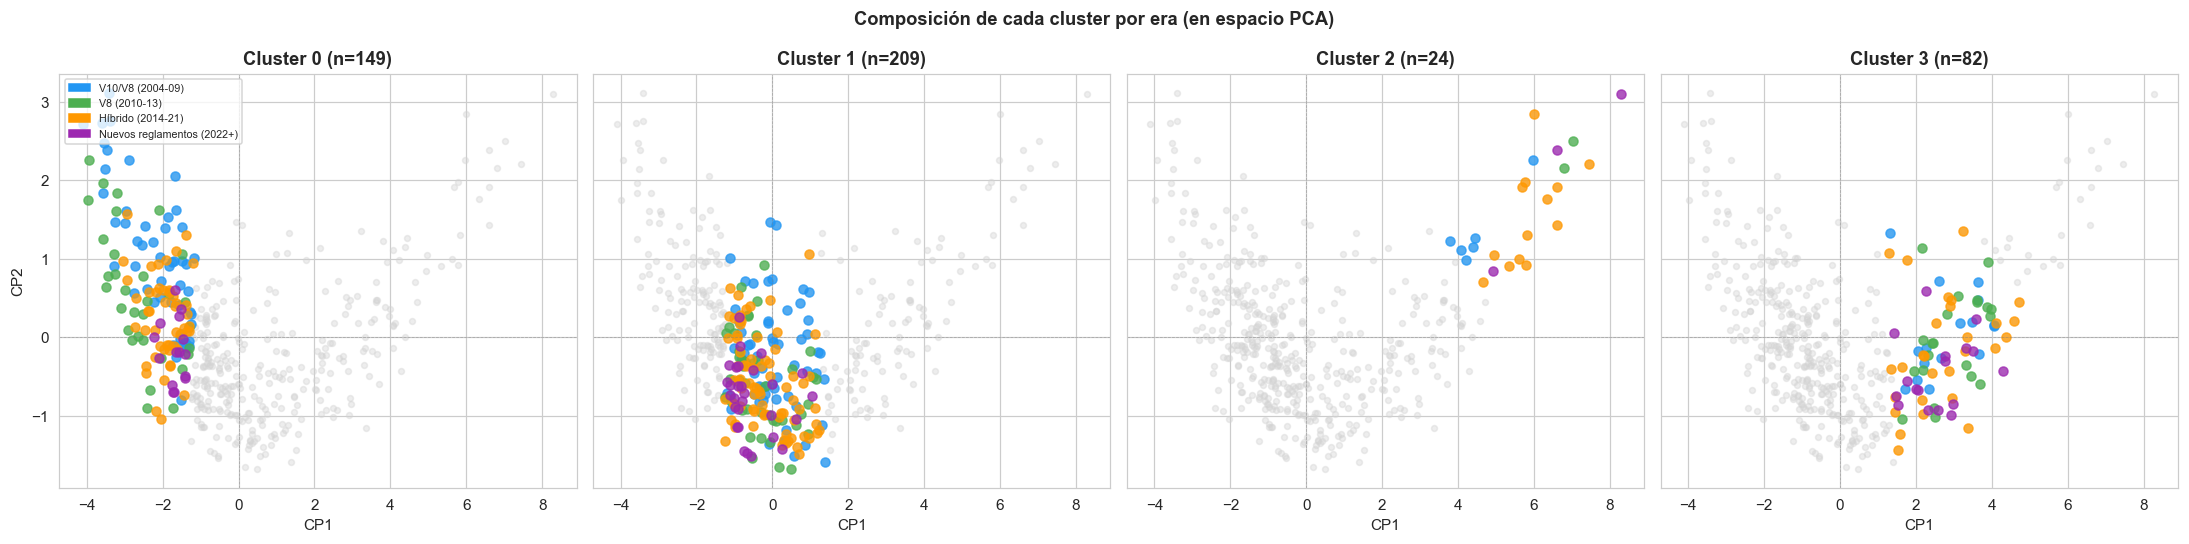

In [60]:
fig, axes = plt.subplots(1, K_FINAL, figsize=(5 * K_FINAL, 5), sharey=True)

era_order = list(ERA_COLORS.keys())

for c in range(K_FINAL):
    ax = axes[c]
    # Fondo: todos los puntos en gris
    ax.scatter(clust_df['CP1'], clust_df['CP2'], c='lightgray', s=15, alpha=0.4, zorder=1)
    # Puntos del cluster c coloreados por era
    grp = clust_df[clust_df['cluster'] == c]
    for era in era_order:
        sub = grp[grp['era'] == era]
        ax.scatter(sub['CP1'], sub['CP2'], c=ERA_COLORS[era],
                   label=era, alpha=0.75, s=35, zorder=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(f'Cluster {c} (n={len(grp)})', fontweight='bold')
    ax.set_xlabel('CP1')
    if c == 0:
        ax.set_ylabel('CP2')

# Leyenda única en el primer subplot
handles = [mpatches.Patch(color=ERA_COLORS[e], label=e) for e in era_order]
axes[0].legend(handles=handles, fontsize=7, loc='upper left')

fig.suptitle('Composición de cada cluster por era (en espacio PCA)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_por_era.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Exploración de cada cluster

### 7.1 Pilotos más representativos de cada cluster (menor distancia al centroide)

In [61]:
from numpy.linalg import norm

centers = km_final.cluster_centers_

for c in range(K_FINAL):
    idx_c = clust_df[clust_df['cluster'] == c].index
    X_c   = X_scaled[clust_df.index.get_indexer(idx_c)]
    dists = norm(X_c - centers[c], axis=1)
    closest_idx = idx_c[np.argsort(dists)[:8]]
    reps = clust_df.loc[closest_idx, ['driver_name', 'year', 'constructor',
                                       'points_per_race', 'win_rate',
                                       'podium_rate', 'dnf_rate']].round(3)
    print(f"\n=== Cluster {c} — 8 pilotos más cercanos al centroide ===")
    print(reps.to_string(index=False))


=== Cluster 0 — 8 pilotos más cercanos al centroide ===
      driver_name  year  constructor  points_per_race  win_rate  podium_rate  dnf_rate
  Marcus Ericsson  2017       Sauber            0.000       0.0          0.0     0.300
 Anthony Davidson  2007  Super Aguri            0.000       0.0          0.0     0.294
    Jolyon Palmer  2016      Renault            0.048       0.0          0.0     0.286
  Brendon Hartley  2018   Toro Rosso            0.190       0.0          0.0     0.286
   Logan Sargeant  2023     Williams            0.045       0.0          0.0     0.227
  Kevin Magnussen  2020 Haas F1 Team            0.059       0.0          0.0     0.353
Heikki Kovalainen  2011        Lotus            0.000       0.0          0.0     0.263
    Jenson Button  2015      McLaren            0.842       0.0          0.0     0.316

=== Cluster 1 — 8 pilotos más cercanos al centroide ===
         driver_name  year  constructor  points_per_race  win_rate  podium_rate  dnf_rate
        Felip

### 7.2 Distribución de variables por cluster (boxplots)

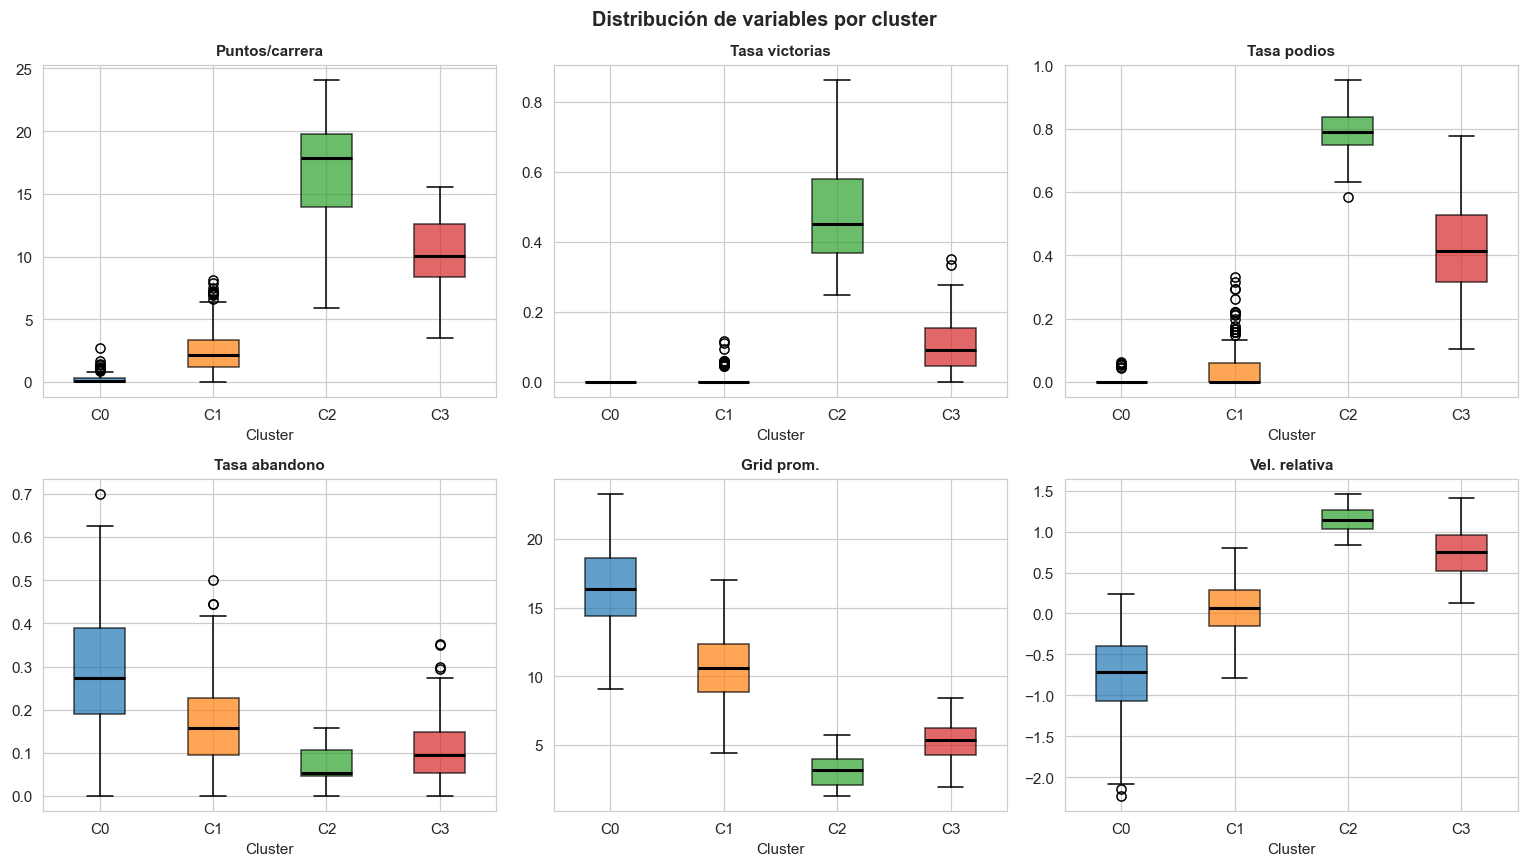

In [62]:
vars_plot = ['points_per_race', 'win_rate', 'podium_rate', 'dnf_rate',
             'avg_grid', 'avg_rel_speed']
labels_plot = {v: LABELS_SHORT[v] for v in vars_plot}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, var in enumerate(vars_plot):
    data_by_cluster = [clust_df[clust_df['cluster'] == c][var].dropna().values
                       for c in range(K_FINAL)]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette[:K_FINAL]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(labels_plot[var], fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticklabels([f'C{c}' for c in range(K_FINAL)])

fig.suptitle('Distribución de variables por cluster',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'cluster_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Interpretación de los clusters

*(Actualizar los nombres propuestos con los resultados exactos obtenidos arriba.)*

---

Con **k=4** se obtienen cuatro grupos con una interpretación clara en términos del dominio F1:

| Cluster | Nombre sugerido | Perfil cuantitativo | Ejemplos representativos |
|---------|----------------|---------------------|-------------------------|
| **C0** | **Equipos débiles / sin puntos** | Grid prom. alto, 0 victorias, 0 podios, alto abandono, vel. relativa negativa | Ericsson (Sauber 17), Sargeant (Williams 23), Davidson (Super Aguri 07) |
| **C1** | **Pelotón medio** | Pocos puntos (1-4 por carrera), sin victorias, bajo abandono, grid intermedio | Massa (Williams 16), Stroll (AM 23), Heidfeld (BMW 06), Alonso (McLaren 16) |
| **C2** | **Temporadas dominantes** | ~18-20 pts/carrera, 40-55% victorias, >70% podios, bajo abandono, alta velocidad | Hamilton (2015-2021), Rosberg (2016), Verstappen (2021-23) |
| **C3** | **Frontrunners / candidatos** | ~10-13 pts/carrera, 5-10% victorias, 35-50% podios, abandono moderado | Vettel (Ferrari 19), Leclerc (19), Button (McLaren 10), Pérez (RB 22-23) |

**Observaciones clave:**
- El Cluster C2 es el más reducido (24 obs.) y captura exclusivamente las temporadas de dominancia absoluta.
- El Cluster C1 es el más grande (209 obs.) e incluye la mayor diversidad: desde pilotos de mitad de grilla hasta ex-campeones en autos no competitivos (ej. Alonso en McLaren-Honda 2016).
- La silueta global de k=4 (≈0.33) es inferior a la de k=2 (0.48), lo que refleja que la frontera entre C1 y C3 es menos nítida que la gran separación entre campeones y no-campeones; sin embargo, k=4 aporta mayor valor interpretativo para el análisis del dominio.


In [63]:
# Resumen cuantitativo final
print("=== Perfil cuantitativo de clusters ===")
summary = clust_df.groupby('cluster')[NUMERIC_VARS + ['n_races']].agg(['mean','std']).round(3)
print(summary.to_string())
print(f"\nSilueta global (k={K_FINAL}): {silhouette_score(X_scaled, clust_df['cluster']):.4f}")

=== Perfil cuantitativo de clusters ===
        avg_grid        avg_pos_order        points_per_race        win_rate        podium_rate        dnf_rate        avg_rel_speed        n_races       
            mean    std          mean    std            mean    std     mean    std        mean    std     mean    std          mean    std    mean    std
cluster                                                                                                                                                   
0         16.606  2.981        15.694  1.886           0.255  0.397    0.000  0.000       0.003  0.013    0.287  0.137        -0.786  0.525  17.128  4.480
1         10.653  2.548        10.980  1.909           2.551  1.852    0.005  0.018       0.048  0.071    0.168  0.100         0.056  0.312  18.727  3.371
2          3.141  1.177         3.342  0.892          15.999  5.638    0.484  0.157       0.780  0.092    0.070  0.048         1.143  0.172  19.792  1.865
3          5.278  1.533       

## 9. Comparación con clustering jerárquico

Verificamos que los clusters de K-Means sean consistentes con los grupos que emergen del corte del dendrograma al mismo número de clusters.

In [64]:
# Asignar clusters jerárquicos con el mismo k
clust_df['cluster_hier'] = fcluster(Z, K_FINAL, criterion='maxclust') - 1  # 0-indexado

# Tabla de contingencia: K-Means vs Jerárquico
contingencia = pd.crosstab(
    clust_df['cluster'],
    clust_df['cluster_hier'],
    rownames=['K-Means'],
    colnames=['Jerárquico']
)
print("Tabla de contingencia (K-Means vs Clustering Jerárquico):")
print(contingencia)

# Silueta del jerárquico
sil_hier = silhouette_score(X_scaled, clust_df['cluster_hier'])
print(f"\nSilueta K-Means:     {silhouette_score(X_scaled, clust_df['cluster']):.4f}")
print(f"Silueta Jerárquico:  {sil_hier:.4f}")

Tabla de contingencia (K-Means vs Clustering Jerárquico):
Jerárquico   0   1   2    3
K-Means                    
0            0  56   0   93
1            0   0  61  148
2           24   0   0    0
3           65   0  15    2

Silueta K-Means:     0.3260
Silueta Jerárquico:  0.2599


### 9.2 Adjusted Rand Index (ARI)

El *Adjusted Rand Index* cuantifica el grado de acuerdo entre dos particiones corrigiendo por azar. Toma valores en [−1, 1]: valores cercanos a 1 indican alta concordancia; valores cercanos a 0 indican acuerdo equivalente al azar.

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(clust_df['cluster'], clust_df['cluster_hier'])

if ari >= 0.75:
    interp = "alta concordancia — ambos métodos producen particiones similares"
elif ari >= 0.50:
    interp = "concordancia moderada — acuerdo sustancial en la estructura de grupos"
else:
    interp = "concordancia baja — los métodos difieren en la asignación de observaciones"

print(f"Adjusted Rand Index (K-Means vs Jerárquico): {ari:.4f}")
print(f"Interpretación: {interp}")
print()
print(f"Resumen comparativo (k={K_FINAL}):")
print(f"  Silueta K-Means:    {silhouette_score(X_scaled, clust_df['cluster']):.4f}")
print(f"  Silueta Jerárquico: {silhouette_score(X_scaled, clust_df['cluster_hier']):.4f}")
print(f"  ARI:                {ari:.4f}")